# Hypothesis 1 & 2 — Timing and Renovation ROI (Price/Sqft Middle-Class Definition)

This notebook reruns the analyses from `03_hypothesis_1.ipynb` (sale timing) and `04_hypothesis_2.ipynb` (grade/condition/renovation), but replaces every prior "middle-class" segment definition with **`df_middle_class_zip_pps`** — the price-per-sqft tercile classification built in `02_middle_class_neighbourhoods.ipynb`. That definition was adopted as final because raw average price conflates house size with location cost, while price/sqft isolates the location premium itself (see `02_middle_class_neighbourhoods.ipynb` for the full reconciliation between the two candidate definitions).

**Note on prior inconsistency:** `03_hypothesis_1.ipynb` used a mean-price tercile (`middle_class_zips`), and `04_hypothesis_2.ipynb` used a *different* median-price tercile (`neighborhood_class`, via `pd.qcut`) — the two didn't even match each other, let alone the price/sqft-based definition used here. This notebook standardizes both analyses on the single agreed-upon `df_middle_class_zip_pps` definition, so results are directly comparable.

**Input:** `housing_cleaned.pkl` (cleaned dataset from `01_cleanfinal.ipynb`)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load the cleaned dataset and rebuild the price/sqft-based middle-class classification

Reproduces the classification steps from `02_middle_class_neighbourhoods.ipynb`: average `price_per_sqft` per zipcode, tercile cutoffs (`p33`/`p67`), and the resulting middle-class zipcode filter (`df_middle_class_zip_pps`).

In [2]:
df = pd.read_pickle("../data/housing_cleaned.pkl")
df["date"] = pd.to_datetime(df["date"], format="%Y-%m-%d")
df["sale_month"] = df["date"].dt.month
df["price_per_sqft"] = df["price"] / df["sqft_living"]
df["is_renovated"] = df["yr_renovated"] != 0

avg_price_per_sqft = df.groupby("zipcode")["price_per_sqft"].mean().sort_values(ascending=False)
p33 = avg_price_per_sqft.quantile(0.33)
p67 = avg_price_per_sqft.quantile(0.67)
middle_segment = avg_price_per_sqft[(avg_price_per_sqft >= p33) & (avg_price_per_sqft <= p67)]

middle_class_zip_list_pps = middle_segment.index.tolist()
df_middle_class_zip_pps = df[df["zipcode"].isin(middle_class_zip_list_pps)].reset_index(drop=True)

print(f"{len(middle_class_zip_list_pps)} middle-class zipcodes (price/sqft basis)")
print(f"{len(df_middle_class_zip_pps)} houses ({len(df_middle_class_zip_pps) / len(df):.1%} of the market)")

24 middle-class zipcodes (price/sqft basis)
7604 houses (35.2% of the market)


**Observation:** 7,604 houses (35.2% of the market) fall in the 24 price/sqft-based middle-class zipcodes — close to, but not identical to, the 7,532 houses (34.9%) covered by the original price-based `middle_class_zips` definition in `03_hypothesis_1.ipynb`. The difference reflects the 11/24 zipcodes that reclassified between the two definitions (see `02_middle_class_neighbourhoods.ipynb`).

---
## Hypothesis 1: Sale price varies by period of the year
**Research question:** Does the timing of the sale affect price? Reruns the monthly price/sales analysis from `03_hypothesis_1.ipynb`, with the middle-class segment now defined by `df_middle_class_zip_pps`.

### Average price by month (all zipcodes)

In [3]:
avg_price_by_month = df.groupby("sale_month")["price"].mean().sort_values(ascending=False)
avg_price_by_month

sale_month
4     562215.615074
6     557534.318182
5     550849.746893
7     544892.161013
3     544057.683200
10    539439.447228
8     536655.212481
9     529723.517787
1     525963.251534
12    524799.902041
11    522359.903478
2     508520.051323
Name: price, dtype: float64

### Average price by month (middle-class zipcodes, price/sqft basis)

In [4]:
avg_price_by_month_middle_pps = df_middle_class_zip_pps.groupby("sale_month")["price"].mean().sort_values(ascending=False)
avg_price_by_month_middle_pps

sale_month
4     555563.563750
6     539496.363519
3     531845.118227
7     526162.229630
8     525988.488571
11    525793.436992
10    520017.756714
9     517699.431596
5     516913.276102
1     516352.295265
12    515480.867041
2     510907.698565
Name: price, dtype: float64

In [5]:
print(f"Highest price month: {avg_price_by_month_middle_pps.idxmax()}")
print(f"Highest price value: {avg_price_by_month_middle_pps.max():,.0f}")
print(f"Lowest price month: {avg_price_by_month_middle_pps.idxmin()}")
print(f"Lowest price value: {avg_price_by_month_middle_pps.min():,.0f}")

Highest price month: 4
Highest price value: 555,564
Lowest price month: 2
Lowest price value: 510,908


In [6]:
price_difference_middle_pps = avg_price_by_month_middle_pps.max() - avg_price_by_month_middle_pps.min()
price_percentage_middle_pps = (price_difference_middle_pps / avg_price_by_month_middle_pps.min()) * 100
print(price_difference_middle_pps, price_percentage_middle_pps)

44655.8651854067 8.7404956532987


**Observation:** April remains the strongest month ($555,564 average), consistent with the original price-based analysis ($541,898). But the *weakest* month shifts from September (original) to **February** ($510,908) under the price/sqft-based segment, and the swing is nearly identical (8.74% vs. 8.90% originally). The next-best months after April also shift — **April, June, March** are the top three here, vs. **April, July, January** originally. The headline "list in spring" recommendation still holds, but the specific secondary months worth targeting have changed.

### Chart: price by month (middle-class zipcodes, price/sqft basis)

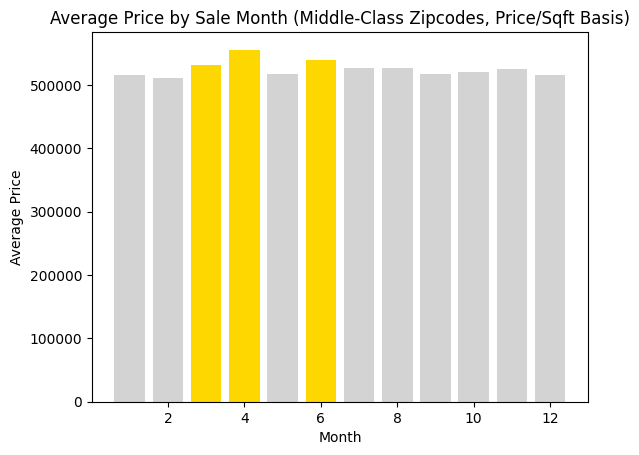

In [7]:
top_3_months_pps = avg_price_by_month_middle_pps.sort_values(ascending=False).head(3).index.tolist()

highlight_colour = "#FFD700"
default_colour = "#D3D3D3"

bar_colours = [highlight_colour if month in top_3_months_pps else default_colour
               for month in avg_price_by_month_middle_pps.sort_index().index]

fig, ax = plt.subplots()
ax.bar(avg_price_by_month_middle_pps.sort_index().index, avg_price_by_month_middle_pps.sort_index().values, color=bar_colours)
ax.set_title("Average Price by Sale Month (Middle-Class Zipcodes, Price/Sqft Basis)")
ax.set_xlabel("Month")
ax.set_ylabel("Average Price")
plt.show()

### Chart: price by month (all zipcodes)

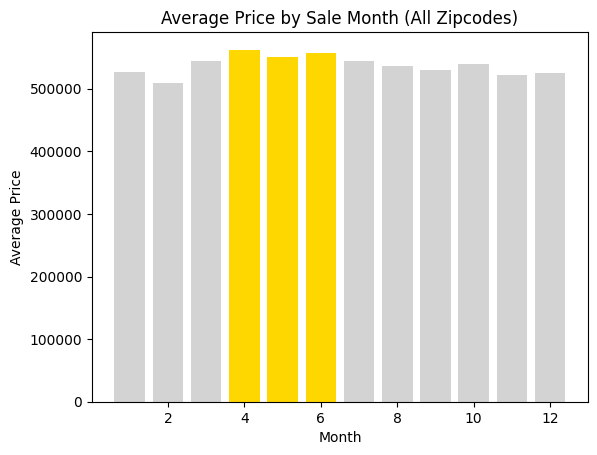

In [8]:
top_3_months_all = avg_price_by_month.sort_values(ascending=False).head(3).index.tolist()

bar_colours = [highlight_colour if month in top_3_months_all else default_colour
               for month in avg_price_by_month.sort_index().index]

fig, ax = plt.subplots()
ax.bar(avg_price_by_month.sort_index().index, avg_price_by_month.sort_index().values, color=bar_colours)
ax.set_title("Average Price by Sale Month (All Zipcodes)")
ax.set_xlabel("Month")
ax.set_ylabel("Average Price")
plt.show()

---
## Additional exploration: number of sales by month (middle-class zipcodes, price/sqft basis)

The original notebook computed sales volume across the whole market; here it's computed specifically within the middle-class (price/sqft) segment, since that's the market Bonnie actually competes in.

In [9]:
sales_count_by_month_pps = df_middle_class_zip_pps.groupby("sale_month")["price"].count().sort_index()
sales_count_by_month_pps

sale_month
1     359
2     418
3     609
4     800
5     862
6     773
7     810
8     700
9     614
10    633
11    492
12    534
Name: price, dtype: int64

In [10]:
sales_difference_pps = sales_count_by_month_pps.max() - sales_count_by_month_pps.min()
sales_percentage_pps = (sales_difference_pps / sales_count_by_month_pps.min()) * 100
print(sales_difference_pps, sales_percentage_pps)

503 140.11142061281336


**Observation:** Sales volume swings far more than price — May has 862 sales vs. January's 359, a 140% difference — while price only swings 8.7%. Timing still matters more for market activity than for price, matching the original conclusion.

### Chart: number of sales by month (middle-class zipcodes, price/sqft basis)

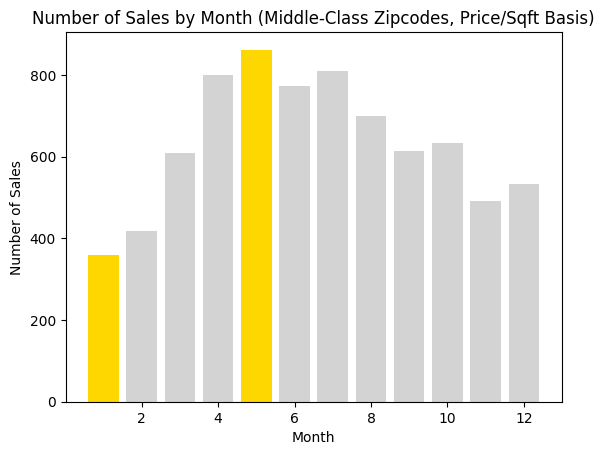

In [11]:
max_month = sales_count_by_month_pps.idxmax()
min_month = sales_count_by_month_pps.idxmin()

bar_colours = [highlight_colour if (month == max_month or month == min_month) else default_colour
               for month in sales_count_by_month_pps.index]

fig, ax = plt.subplots()
ax.bar(sales_count_by_month_pps.index, sales_count_by_month_pps.values, color=bar_colours)
ax.set_title("Number of Sales by Month (Middle-Class Zipcodes, Price/Sqft Basis)")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Sales")
plt.show()

### Is price connected to number of sales, within the middle-class segment?

In [12]:
comparison_pps = pd.DataFrame({
    "avg_price": avg_price_by_month_middle_pps.sort_index(),
    "sales_count": sales_count_by_month_pps.sort_index()
})
comparison_pps

,avg_price,sales_count
sale_month,,
1,516352.295265,359
2,510907.698565,418
3,531845.118227,609
4,555563.563750,800
5,516913.276102,862
6,539496.363519,773
7,526162.229630,810
8,525988.488571,700
9,517699.431596,614


In [13]:
comparison_pps.corr()

,avg_price,sales_count
avg_price,1.000000,0.531447
sales_count,0.531447,1.000000


**Observation:** Within the middle-class (price/sqft) segment, average price and sales volume correlate at **0.53** — a moderate positive relationship, but notably weaker than the **0.86** correlation `03_hypothesis_1.ipynb` found across the whole market (that check wasn't previously run on the middle-class segment specifically). The price-volume link that holds market-wide is less pronounced once the market is narrowed to Bonnie's segment.

---
## Hypothesis 2: Renovation / Condition / Grade correspond to higher price points

Reruns the analysis from `04_hypothesis_2.ipynb`. First on the whole market (unchanged, for baseline context), then within the price/sqft-based middle-class segment (`df_middle_class_zip_pps`), replacing the original's separate median-price-tercile ("bonnie") segment.

### Price by grade (whole market)

       count     median          mean
grade                                
3          1   262000.0  2.620000e+05
4         27   200000.0  2.120019e+05
5        242   228700.0  2.485240e+05
6       2038   275276.5  3.019166e+05
7       8974   375000.0  4.025946e+05
8       6065   510000.0  5.429868e+05
9       2615   720000.0  7.737382e+05
10      1134   914327.0  1.072347e+06
11       399  1280000.0  1.497792e+06
12        89  1820000.0  2.202528e+06
13        13  2980000.0  3.710769e+06

Correlation grade <-> price: 0.67


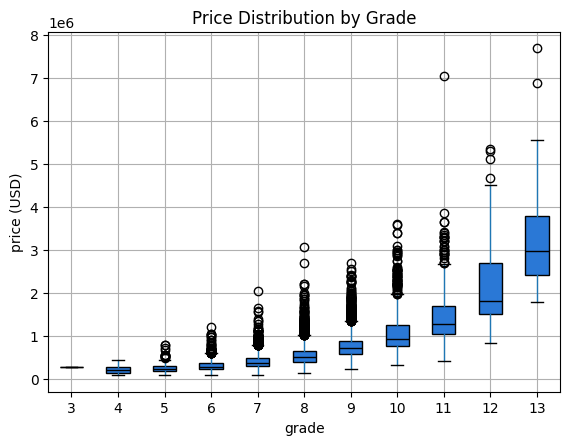

In [14]:
grade_price = df.groupby("grade")["price"].agg(["count", "median", "mean"])
print(grade_price)
print("\nCorrelation grade <-> price:", df["grade"].corr(df["price"]).round(2))

fig, ax = plt.subplots()
df.boxplot(column="price", by="grade", ax=ax, patch_artist=True,
           boxprops={"facecolor": "#2a78d6", "edgecolor": "black"},
           medianprops={"color": "black"})
ax.set_title("Price Distribution by Grade")
ax.set_xlabel("grade")
ax.set_ylabel("price (USD)")
plt.suptitle("")
plt.show()

**Observation:** Unchanged from the original — a strong, near-monotonic relationship, correlation **0.67**, median price rising from $262,000 (grade 3) to $2,980,000 (grade 13). This doesn't depend on the middle-class definition since it's computed on the whole market.

### Price by condition (whole market)

           count    median           mean
condition                                
1             29  270000.0  341067.241379
2            170  279000.0  328178.758824
3          14020  450250.0  542173.057347
4           5677  440000.0  521374.450414
5           1701  526000.0  612577.742504

Correlation condition <-> price: 0.04


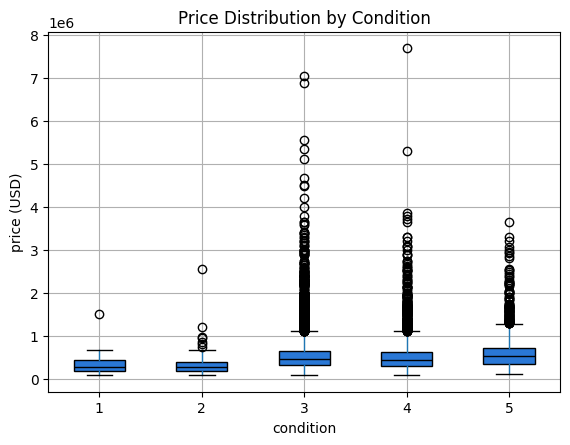

In [15]:
condition_price = df.groupby("condition")["price"].agg(["count", "median", "mean"])
print(condition_price)
print("\nCorrelation condition <-> price:", df["condition"].corr(df["price"]).round(2))

fig, ax = plt.subplots()
df.boxplot(column="price", by="condition", ax=ax, patch_artist=True,
           boxprops={"facecolor": "#2a78d6", "edgecolor": "black"},
           medianprops={"color": "black"})
ax.set_title("Price Distribution by Condition")
ax.set_xlabel("condition")
ax.set_ylabel("price (USD)")
plt.suptitle("")
plt.show()

**Observation:** Also unchanged — weak relationship, correlation **0.04**. `condition` alone barely explains price across the whole market.

### Renovated vs. non-renovated houses (whole market)

              count    median           mean
is_renovated                                
False         20853  449000.0  532140.319858
True            744  607502.0  768901.892473

                  median        mean
is_renovated                        
False         243.190661  262.102755
True          301.562882  321.338135

Correlation is_renovated <-> price: 0.12


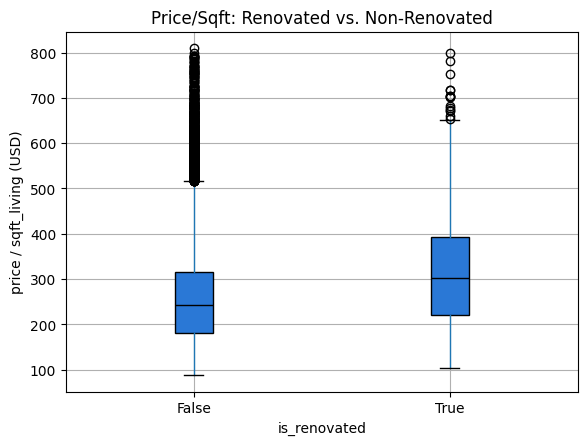

In [16]:
print(df.groupby("is_renovated")["price"].agg(["count", "median", "mean"]))
print()
print(df.groupby("is_renovated")["price_per_sqft"].agg(["median", "mean"]))
print("\nCorrelation is_renovated <-> price:", df["is_renovated"].astype(int).corr(df["price"]).round(2))

fig, ax = plt.subplots()
df.boxplot(column="price_per_sqft", by="is_renovated", ax=ax, patch_artist=True,
           boxprops={"facecolor": "#2a78d6", "edgecolor": "black"},
           medianprops={"color": "black"})
ax.set_title("Price/Sqft: Renovated vs. Non-Renovated")
ax.set_xlabel("is_renovated")
ax.set_ylabel("price / sqft_living (USD)")
plt.suptitle("")
plt.show()

**Observation:** Unchanged — renovated homes sell for a median of **$607,502** vs. **$449,000** for non-renovated ones (+35%), median price/sqft **$301.56** vs. **$243.19** (+24%), correlation **0.12**.

### `condition == 3` vs. other conditions — within the middle-class (price/sqft) segment

In [17]:
cond3_summary_pps = df_middle_class_zip_pps.groupby(df_middle_class_zip_pps["condition"] == 3)["price_per_sqft"].agg(["count", "median", "mean"])
cond3_summary_pps

,count,median,mean
condition,,,
False,2202,251.835017,263.180194
True,5402,246.153846,251.386657


**Observation:** Within the middle-class (price/sqft) segment, `condition == 3` homes (5,402 houses) have a median price/sqft of **$246.15**, vs. **$251.84** for better-rated homes (2,202 houses) — a discount of roughly **2.3%**. This is much smaller than the **~10% discount** (`$249` vs. `$276`/sqft) that `04_hypothesis_2.ipynb` found under its median-price-tercile segment — the `condition == 3` discount is real but far less pronounced under the price/sqft-based definition.

### ROI analysis: does renovating before selling pay off, within the middle-class (price/sqft) segment?

Bonnie's actual question: her house is `condition == 3`. Would renovating before selling raise the price enough to be worth it? Comparing already-renovated vs. non-renovated homes *within* `condition == 3`, in the middle-class (price/sqft) segment.

             price                          price_per_sqft              \
             count    median           mean          count      median   
is_renovated                                                             
False         5246  485000.0  541387.979032           5246  246.206365   
True           156  458000.0  547359.198718            156  238.343195   

                          
                    mean  
is_renovated              
False         251.303215  
True          254.192642  

Median price renovated: 458,000 vs. non-renovated: 485,000 -> -5.6%
Median price/sqft renovated: 238 vs. non-renovated: 246 -> -3.2%
Correlation is_renovated <-> price: 0.0037
n renovated: 156 / n total condition==3: 5402


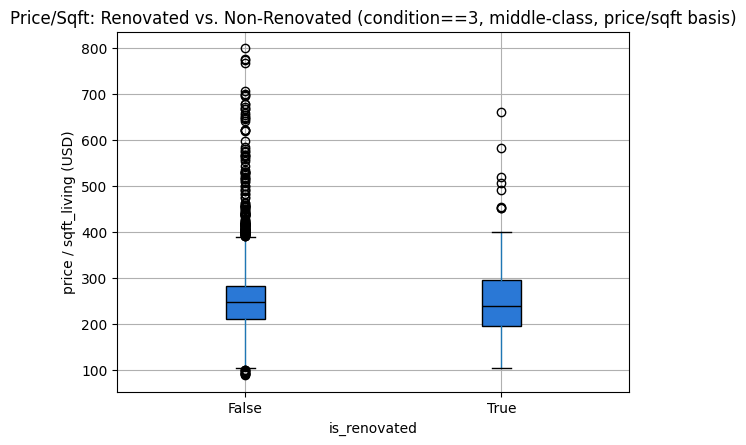

In [18]:
mc_cond3_pps = df_middle_class_zip_pps[df_middle_class_zip_pps["condition"] == 3].copy()

print(mc_cond3_pps.groupby("is_renovated")[["price", "price_per_sqft"]].agg(["count", "median", "mean"]))

median_price_reno = mc_cond3_pps.loc[mc_cond3_pps["is_renovated"], "price"].median()
median_price_noreno = mc_cond3_pps.loc[~mc_cond3_pps["is_renovated"], "price"].median()
price_uplift_pct = (median_price_reno / median_price_noreno - 1) * 100

median_psf_reno = mc_cond3_pps.loc[mc_cond3_pps["is_renovated"], "price_per_sqft"].median()
median_psf_noreno = mc_cond3_pps.loc[~mc_cond3_pps["is_renovated"], "price_per_sqft"].median()
psf_uplift_pct = (median_psf_reno / median_psf_noreno - 1) * 100

print(f"\nMedian price renovated: {median_price_reno:,.0f} vs. non-renovated: {median_price_noreno:,.0f} -> {price_uplift_pct:+.1f}%")
print(f"Median price/sqft renovated: {median_psf_reno:,.0f} vs. non-renovated: {median_psf_noreno:,.0f} -> {psf_uplift_pct:+.1f}%")
print("Correlation is_renovated <-> price:", mc_cond3_pps["is_renovated"].astype(int).corr(mc_cond3_pps["price"]).round(4))
print(f"n renovated: {mc_cond3_pps['is_renovated'].sum()} / n total condition==3: {len(mc_cond3_pps)}")

fig, ax = plt.subplots()
mc_cond3_pps.boxplot(column="price_per_sqft", by="is_renovated", ax=ax, patch_artist=True,
                      boxprops={"facecolor": "#2a78d6", "edgecolor": "black"},
                      medianprops={"color": "black"})
ax.set_title("Price/Sqft: Renovated vs. Non-Renovated (condition==3, middle-class, price/sqft basis)")
ax.set_xlabel("is_renovated")
ax.set_ylabel("price / sqft_living (USD)")
plt.suptitle("")
plt.show()

**Observation — this reverses the original conclusion.** Within `condition == 3` in the price/sqft-based middle-class segment, renovated homes (156 of 5,402, ~2.9%) show a median price of **$458,000** vs. **$485,000** for non-renovated ones — that's **-5.6%**, not a premium. Median price/sqft is also lower for renovated homes (**$238.34** vs. **$246.21**, **-3.2%**), and the correlation between `is_renovated` and `price` is essentially **zero (0.0037)**.

This is the opposite direction from `04_hypothesis_2.ipynb`'s finding of a **+36.7%** median price / **+21.7%** price/sqft renovation premium. The renovated sample is small under both definitions (156 here vs. 201 originally), so neither result is highly statistically robust — but the fact that the *sign* of the effect flips depending on which "middle-class" definition is used is itself an important finding: it suggests the original renovation-premium conclusion may have been partly an artifact of which zipcodes the flawed price-tercile definition happened to include, rather than a robust renovation effect. **This should be flagged prominently in the writeup** — the "renovate before selling" recommendation for Bonnie is no longer well-supported by the price data alone.

### `grade` within the middle-class (price/sqft) segment (context)

       count      median        mean
grade                               
4         13  322.077922  377.976969
5         66  250.000000  299.942829
6        781  260.245902  272.372462
7       2932  240.601504  247.746446
8       2106  247.792398  250.813036
9       1020  247.838663  253.976819
10       499  251.002825  265.552689
11       158  265.024481  279.442957
12        29  308.115543  336.438592

Correlation grade <-> price (middle-class, price/sqft basis): 0.75


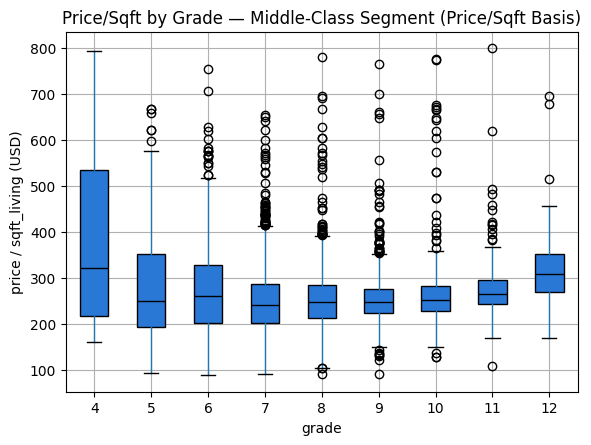

In [19]:
mc_grade_pps = df_middle_class_zip_pps.groupby("grade")["price_per_sqft"].agg(["count", "median", "mean"])
print(mc_grade_pps)
print("\nCorrelation grade <-> price (middle-class, price/sqft basis):",
      df_middle_class_zip_pps["grade"].corr(df_middle_class_zip_pps["price"]).round(2))

fig, ax = plt.subplots()
df_middle_class_zip_pps.boxplot(column="price_per_sqft", by="grade", ax=ax, patch_artist=True,
                                 boxprops={"facecolor": "#2a78d6", "edgecolor": "black"},
                                 medianprops={"color": "black"})
ax.set_title("Price/Sqft by Grade — Middle-Class Segment (Price/Sqft Basis)")
ax.set_xlabel("grade")
ax.set_ylabel("price / sqft_living (USD)")
plt.suptitle("")
plt.show()

**Observation:** `grade` remains a strong driver within the middle-class (price/sqft) segment — correlation **0.75**, even stronger than the whole-market correlation (0.67) and the original mid-class version (0.65). As before, `grade` is relevant context for Bonnie but not directly actionable — she can typically change her home's `condition` (via renovation), not its `grade`.

---
## Summary

| Analysis | Original (price-tercile / median-price-tercile) | Price/sqft-tercile (`df_middle_class_zip_pps`) |
|---|---|---|
| Best month to sell | April ($541,898) | April ($555,564) — unchanged |
| Weakest month | September ($497,588) | February ($510,908) — **changed** |
| Top 3 months | April, July, January | April, June, March — **changed** |
| Price swing by month | 8.9% | 8.7% — essentially unchanged |
| Price vs. sales-volume correlation | 0.86 (whole market) | 0.53 (within middle-class segment) — **weaker, newly checked at this granularity** |
| `grade` <-> price correlation | 0.65–0.67 | 0.75 — **stronger** |
| `condition==3` discount | ~10% ($249 vs. $276/sqft) | ~2.3% ($246 vs. $252/sqft) — **much smaller** |
| Renovation premium (`condition==3`) | +36.7% price, +21.7% price/sqft | **-5.6% price, -3.2% price/sqft** — **reversed** |

**Bottom line:** switching to the price/sqft-based middle-class definition mostly preserves the timing story (list in spring), but materially changes the renovation-ROI conclusion — the clear premium found originally does not hold up, and even points slightly negative, once the middle-class segment is defined by price/sqft instead of raw price. Given both renovated samples are small (~150–200 homes), this isn't proof that renovation *never* helps, but it removes the strongest piece of evidence for recommending it, and should be reflected in Bonnie's final recommendations rather than carrying forward the original +36.7% figure.